# 11 — Dasar Visualisasi dengan Matplotlib

Di notebook ini kita belajar **Matplotlib** — pustaka visualisasi
paling fundamental di Python — mulai dari line, bar, histogram, hingga pie dan subplot.
Kita pakai data penjualan nyata agar lebih bermakna.

> 🎯 **Tujuan Pembelajaran**
> - Membuat **line chart**, **bar chart**, **histogram**, dan **pie chart** dengan Matplotlib.
> - Menyusun beberapa grafik dalam satu kanvas memakai **subplot**.
> - Mengkustomisasi grafik: judul, label sumbu, warna, legenda, dan **anotasi**.


## 📊 Tentang Dataset

Kita memakai **Global Superstore**, data transaksi ritel berisi penjualan, profit, segmen pelanggan, dan wilayah. Cocok untuk berlatih beragam jenis grafik.

- **Sumber:** [Kaggle — vivek468/superstore-dataset-final](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)
- **Jumlah data:** 9994 baris × 21 kolom
- **Catatan:** file ini perlu dibaca dengan `encoding="latin-1"`.

| Kolom (penting) | Arti |
|-------|------|
| `Order Date` | Tanggal pesanan |
| `Segment` | Segmen pelanggan (Consumer / Corporate / Home Office) |
| `Region` | Wilayah penjualan (West / East / Central / South) |
| `Category` | Kategori produk |
| `Sales` | Nilai penjualan |
| `Profit` | Keuntungan |
| `Quantity` | Jumlah unit terjual |

## 1. Import Library

- **pandas** & **numpy** → mengolah & mengagregasi data.
- **matplotlib.pyplot** → membuat semua grafik (fokus notebook ini).
- **seaborn** → hanya untuk mengatur tema agar grafik lebih rapi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Import Dataset dari kaggle

In [2]:
!pip install -q kaggle
!kaggle datasets download -d vivek468/superstore-dataset-final

Dataset URL: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final
License(s): other
100% 550k/550k [00:00<00:00, 707kB/s]



In [5]:
#unzip folder
!unzip -q superstore-dataset-final.zip


replace Sample - Superstore.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


## 3. Eksplorasi awal

In [6]:
df = pd.read_csv("/content/Sample - Superstore.csv", encoding="latin-1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Interpretasi:
- Setiap baris merepresentasikan 1 order customer per item

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,9994.0,4997.500000,2885.163629,1.000,2499.25000,4997.5000,7495.750,9994.000
Postal Code,9994.0,55190.379428,32063.693350,1040.000,23223.00000,56430.5000,90008.000,99301.000
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


Interpretasi:
- Terdapat 21 kolom dengan 9994 baris data dalam dataset
- Tidak terdapat missing value dari dataset
- data tanggal masih berupa objek dan perlu diubah menjadi tanggal
- Fokus pada kolom ( Order Date, Sales, Profit, Region an Segment untuk pembuatan visualisasi selanjutnya


## 4. Persiapan data untuk visualisasi

ubah kolom Order Date karna masih bertipe objek atau teks



In [11]:
#Konversi orde date ke datetime
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y", errors="coerce")
print("rentang tanggal: ", df["Order Date"].min().date(), "s/d", df["Order Date"].max().date() )

rentang tanggal:  2014-01-03 s/d 2017-12-30


In [12]:
#Kolom perioder bulanan (yyyy/mm)
df["Month"] = df["Order Date"].dt.to_period("M").dt.to_timestamp()
df[["Order Date", "Month", "Sales", "Profit"]].head()

,Order Date,Month,Sales,Profit
0,2016-11-08,2016-11-01,261.9600,41.9136
1,2016-11-08,2016-11-01,731.9400,219.5820
2,2016-06-12,2016-06-01,14.6200,6.8714
3,2015-10-11,2015-10-01,957.5775,-383.0310
4,2015-10-11,2015-10-01,22.3680,2.5164


Interpretasi:
-  Data tanggal yang sebelumnya teks sudah di konversi menjadi date time, mencakup data beberapa tahun,
- Menambahkan kolom bulan yang akan digunakan untuk meng aggregasi penjualan per bulan



## 5. Exploratori data analisis dengan

membuat berbagai jenis grafik. Setiap grafik diberi judul, label sumbu, dan warna.

#### a) Linechart - Tren Penjualan Bulanan

In [13]:
monthly_sales = df.groupby("Month")["Sales"].sum()
monthly_sales.head()

,Sales
Month,
2014-01-01,14236.895
2014-02-01,4519.892
2014-03-01,55691.009
2014-04-01,28295.345
2014-05-01,23648.287


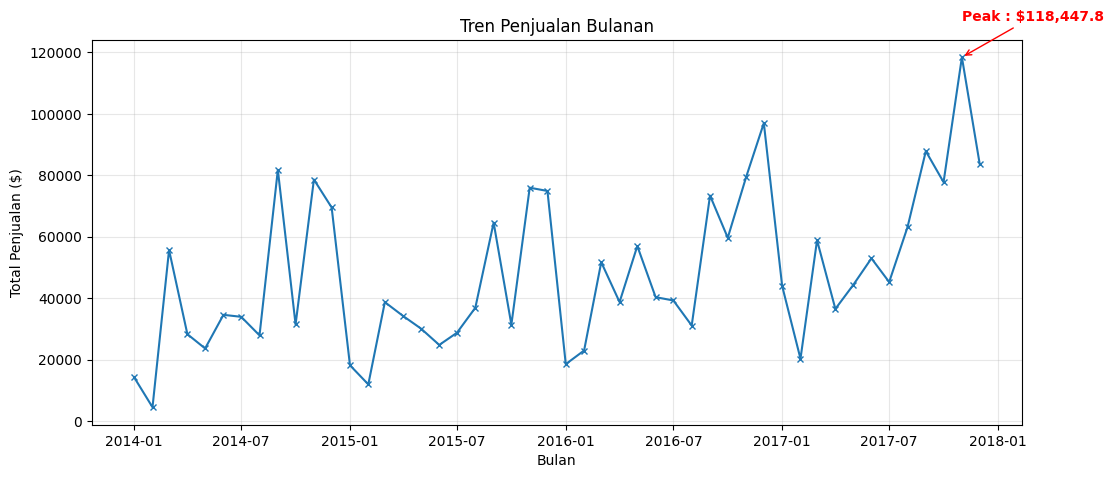

In [22]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker="x",
         markersize=4)
plt.title("Tren Penjualan Bulanan")
plt.xlabel("Bulan")
plt.ylabel("Total Penjualan ($)")

#Anotasi mendetail
peak_month = monthly_sales.idxmax()
peak_sales = monthly_sales.max()
plt.annotate(f"Peak : ${peak_sales:,.1f}",
             xy=(peak_month, peak_sales),
             xytext=(peak_month,peak_sales*1.1),
             arrowprops=dict(arrowstyle="->", color="red"),
             color="red",
             fontweight="bold")
plt.grid(True, alpha=0.3)
plt.show()

Interpretasi:
- Menjelang akhir tahun selalu terjadi peningkatkan penjualan secara besar
- Tren dari tahun ke tahun terlihat naik dengan lonjakan di akhir tahun
- Anotasi diatas menunjukkan bulan dengan penjualan tertinggi
- pola musiman ini penting untuk strategi perencanaan stok barang menjelang peak season

#### b) BarChart - Total Penjualan per Region

In [24]:
sales_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
sales_region

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


Interpretasi:
-  Penjualan didaerah barat adalah penjualan tertinggi di ikuti timur, tengah dan selatan berada di urutan terbawah

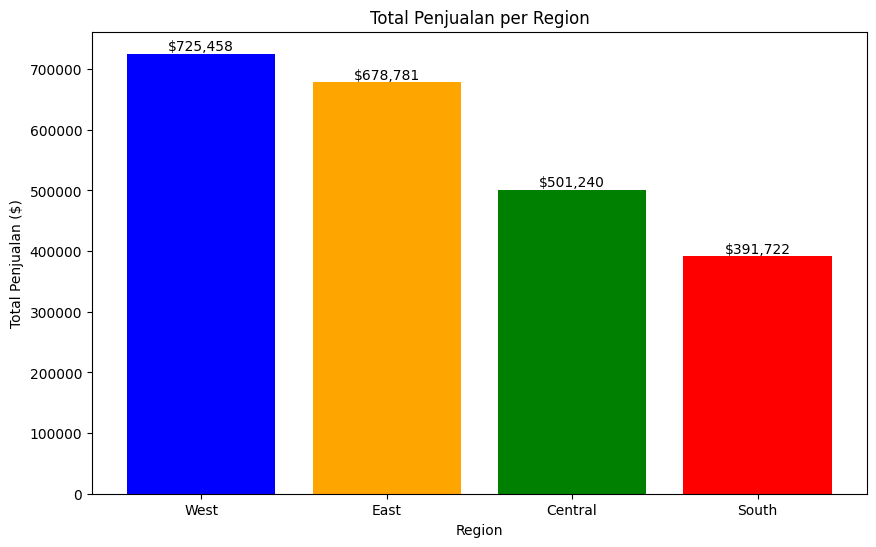

In [34]:
plt.figure(figsize=(10,6))
bars = plt.bar(sales_region.index, sales_region.values,
               color=["blue", "orange", "green", "red"])
plt.title("Total Penjualan per Region")
plt.xlabel("Region")
plt.ylabel("Total Penjualan ($)")

#Anotasikan
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"${bar.get_height():,.0f}",
             ha="center", va="bottom", fontsize=10)
plt.show()


Interpretasi:
- penjualan di daerah barat mencapai $ 725,45 Billion, ikuti timur dengan $ 678,781 Billion, lalu tengah $ 501,24 Billion, dan terendah di selatan dengan $ 391,72  Billion
- Perlu ada strategi Pemasaran khusus untuk meningkatkan penjualan di daerah Selatan
- Promo dan Diskon mungkin diperlukan untuk meningkatkan penjualan di daerah Selatan
- Sebelum melakukan aktivitas pemasaran, pahami dulu prefensi, demografi , daya beli di wilayah Selatan, supaya upaya dan strategi yang dilakukan selanjutnya maskimal dan tidak memakan terlalu banyak cost marketing

#### c) Histogram - Distribusi Profit

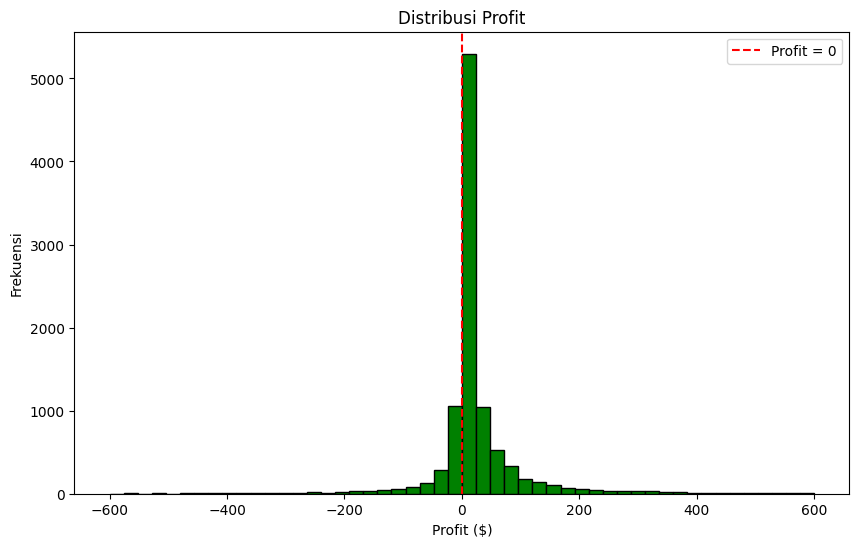

In [44]:
plt.figure(figsize=(10,6))
plt.hist(df["Profit"],
         bins=50,
         color="green",
         edgecolor="black",
         range=(-600, 600))
plt.title("Distribusi Profit")
plt.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Profit = 0")
plt.xlabel("Profit ($)")
plt.ylabel("Frekuensi")
plt.legend()
plt.show()

Interpretasi:
- Mayoritas transaksi memiliki profit yang kecil dan berada disekitar 0
- Garis Merah putus putus ini menandai breakeven point
- Dari grafik didapatin profit berada disebelah kiri dari 0 atau negatif , bisa dikatakan ini adalah transaksi yang memiliki kerugian, bisa diakibatkan oleh diskon, promosi dan aktivitas marketing lainnya

#### d) Pie Chart - Komposisi Penjualan per Segment

In [45]:
sales_segment = df.groupby("Segment")["Sales"].sum()
sales_segment

,Sales
Segment,
Consumer,1.161401e+06
Corporate,7.061464e+05
Home Office,4.296531e+05


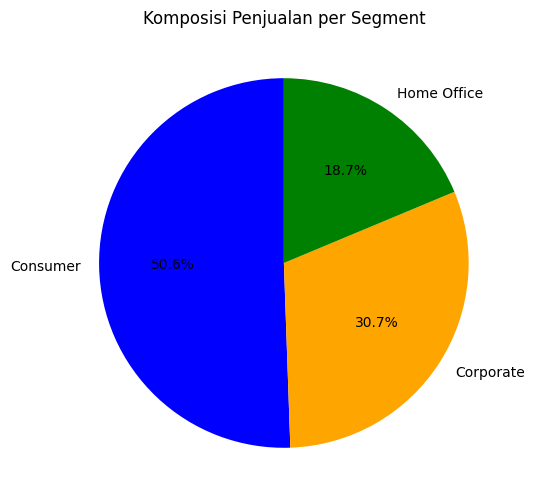

In [47]:
plt.figure(figsize=(10,6))
plt.pie(sales_segment.values,
        labels=sales_segment.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=["blue", "orange", "green"])
plt.title("Komposisi Penjualan per Segment")
plt.show()


Interpretasi:
- Segment Consumer menjadi segment dengan penjualan terbesar diangka 50,6% hampir setengah dari penjualan ada di segment ini
- Corporate Segment ditempat kedua dnegan 30,7% diikuti segment Home Office terakhir sebesar 18,7%
- Untuk mempertahankan retention di segment consumer, perlu diadakan promo dan diskon untuk mempertahankan tingkat retention pembelian di segment consumer


#### e) subplot - Menggabungkan Beberapa Grafik dalam 1 Canvas

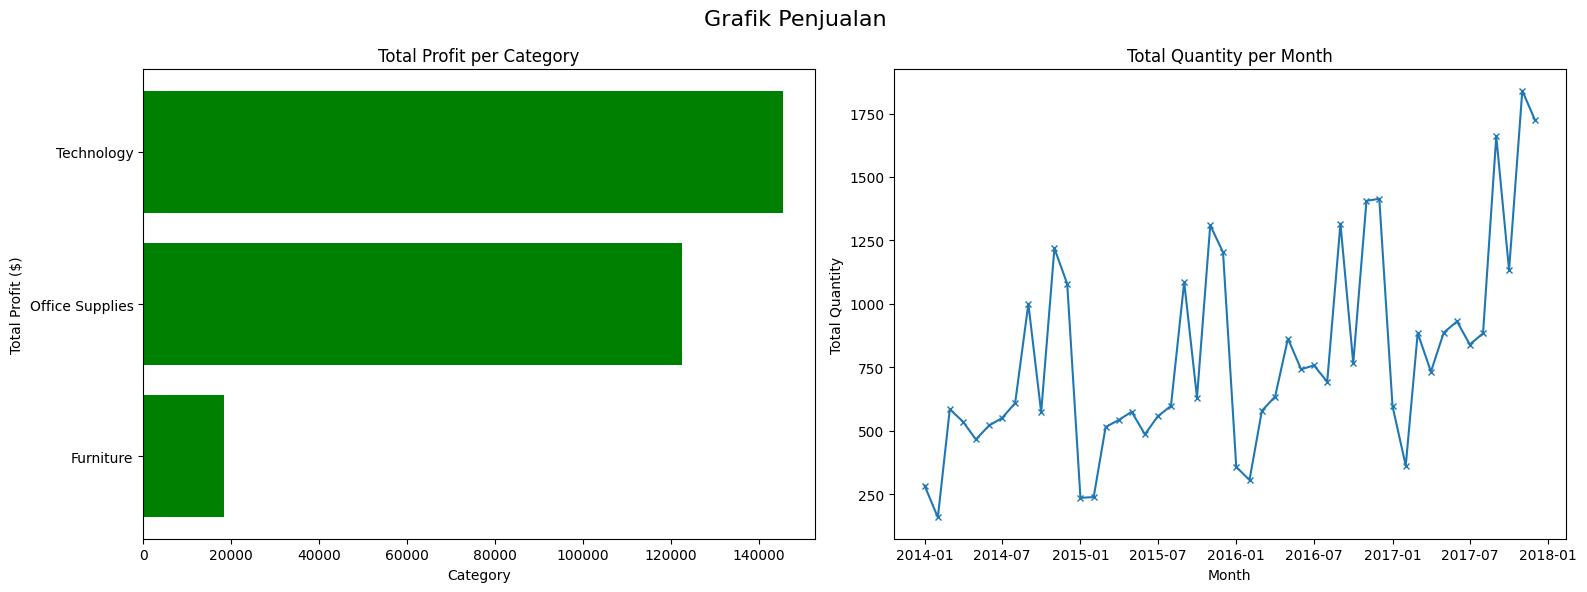

In [63]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16,6))

#left
cat_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=True)
axes[0].barh(cat_profit.index, cat_profit.values, color="green")
axes[0].set_title("Total Profit per Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Total Profit ($)")

#right
qty_mon = df.groupby("Month")["Quantity"].sum()
axes[1].plot(qty_mon.index, qty_mon.values, marker="x", markersize=4)
axes[1].set_title("Total Quantity per Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Total Quantity")


plt.suptitle("Grafik Penjualan", fontsize=16)
plt.tight_layout()
plt.show()


Interpretasi:
- dengan 2 subplot ini kita bisa membandingkan dan melihat dengan perspektif lebih luas
- plot kiri adalah total profit per kategori
- plot kanan adalah tren penjualan setiap bulannya
- subplot ini berguna untuk pembuatan dashboard sederhana

## Kesimpulan & Insight

  - Matplotlib menyediakan blok dasar visualisasi: **line, bar, histogram, pie, subplot**.

  - Kunci grafik yang baik: selalu beri **judul, label sumbu, legenda**, dan **anotasi** bila perlu.

  - Dari data Superstore: penjualan **naik dengan pola musiman akhir tahun**, didominasi region West/East dan segmen Consumer, namun ada **transaksi merugi** yang patut diselidiki.
  
  - Subplot memudahkan menyajikan beberapa cerita data sekaligus.


## 💡 Insight & Jebakan Data

Grafik yang tepat membuat pola bisnis (musim, kontribusi region) langsung terbaca stakeholder tanpa melihat angka mentah — itulah nilai visualisasi.

### ⚠️ Jebakan Data
  - **Pie chart** hanya nyaman untuk **sedikit** kategori (≤5). Untuk banyak kategori, **bar chart**   jauh lebih mudah dibandingkan.

  - `Order Date` terbaca sebagai teks — wajib `pd.to_datetime` sebelum di-`resample`/diurutkan,   kalau tidak urutan waktunya bisa kacau (mis. bulan "10" muncul sebelum "9").